
# NLP Sentiment Analysis Project using IMDB Dataset

#INTRODUCTION

This project focuses on Natural Language Processing (NLP) using the IMDB movie reviews dataset for sentiment analysis. The goal is to classify reviews as positive or negative using machine learning techniques. It includes text preprocessing, feature extraction, model training, and evaluation to understand how computers interpret human language effectively.

In [ ]:
# =====================================================================
# 1. IMPORT LIBRARIES
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
import tensorflow as tf

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

This step loads all required Python libraries for the NLP project. It includes tools for data handling (pandas, numpy), visualization (matplotlib, seaborn), text processing (nltk), machine learning (scikit-learn), and deep learning (tensorflow). These libraries provide the foundation for building and evaluating the sentiment analysis model.

NLTK DOWNLOADS

This step downloads essential Natural Language Processing resources such as tokenizer models and stopword lists. “punkt” and “punkt_tab” help split text into words, while stopwords remove common unnecessary words like “the” and “is.” These resources are required before performing text preprocessing tasks in sentiment analysis.

In [ ]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

REPRODUCIBILITY SETUP

This step ensures that results remain consistent every time the code is run. Random seeds are set for NumPy and TensorFlow so that model training produces the same output. This is important in machine learning experiments because it allows fair comparison and reliable evaluation of model performance.

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

4. LOAD DATASET

This step loads the IMDB movie reviews dataset into a pandas DataFrame. The dataset contains text reviews and sentiment labels. It is a standard dataset for binary sentiment classification tasks. Printing the first rows confirms successful loading and helps verify that the structure of the dataset is correct.

In [ ]:
df = pd.read_csv(
    "/content/IMDB Dataset.csv",
    engine="python",
    on_bad_lines="skip"
)

print("\nDataset Loaded Successfully")
print(df.head())


Dataset Loaded Successfully
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


5. ENCODE TARGET VARIABLE

This step converts sentiment labels into numerical format. Positive reviews are mapped to 1 and negative reviews to 0. Machine learning models cannot process text labels directly, so encoding is necessary. This transformation prepares the dataset for training classification algorithms like Logistic Regression and Neural Networks.

In [ ]:
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

6. TEXT CLEANING FUNCTION

This step prepares raw text for analysis by cleaning it. The function converts text to lowercase, removes HTML tags, punctuation, and stopwords, and applies stemming to reduce words to their root form. This reduces noise in the dataset and improves model accuracy by standardizing input text features.

In [ ]:

stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # safer tokenization (prevents punkt errors)
    try:
        words = word_tokenize(text)
    except:
        words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


# APPLY CLEANING
df["clean_review"] = df["review"].apply(clean_text)

print("\nCleaned Sample:")
print(df[["review", "clean_review"]].head())



Cleaned Sample:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  
0  one review mention watch 1 oz episod youll hoo...  
1  wonder littl product film techniqu unassum old...  
2  thought wonder way spend time hot summer weeke...  
3  basic there famili littl boy jake think there ...  
4  petter mattei love time money visual stun film...  


7. APPLY TEXT CLEANING

This step applies the cleaning function to every review in the dataset. Each text entry is transformed into a simplified version containing only meaningful words. The cleaned text is stored in a new column. This ensures that all reviews are consistently processed before being converted into numerical form for modeling.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_review"],
    df["sentiment"],
    test_size=0.2,
    random_state=42
)


8. TRAIN-TEST SPLIT

This step splits the dataset into training and testing sets. The training set is used to teach the model patterns in the data, while the testing set evaluates performance on unseen data. A random state ensures reproducibility. This step is essential for measuring how well the model generalizes.

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


9. TF-IDF REPRESENTATION

This step converts text into numerical features using TF-IDF (Term Frequency–Inverse Document Frequency). It measures how important a word is in a document relative to the dataset. This representation helps machine learning models understand text data by turning words into meaningful weighted vectors for classification.

In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

pred_lr = lr_model.predict(X_test_tfidf)


print("\nTF-IDF + Logistic Regression Accuracy:",
      accuracy_score(y_test, pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, pred_lr))



TF-IDF + Logistic Regression Accuracy: 0.8857

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



The TF-IDF with Logistic Regression model achieved an accuracy of 0.8857 on the IMDB sentiment dataset. The classification report shows balanced performance between both classes, with precision, recall, and F1-scores around 0.87–0.90. Overall accuracy is about 0.89, indicating strong and consistent performance across positive and negative sentiment predictions.

12. CONFUSION MATRIX

This step visualizes model performance using a confusion matrix. It shows correct and incorrect predictions for each class. The diagonal values represent correct classifications, while off-diagonal values show errors. This helps identify whether the model struggles more with positive or negative sentiment predictions.

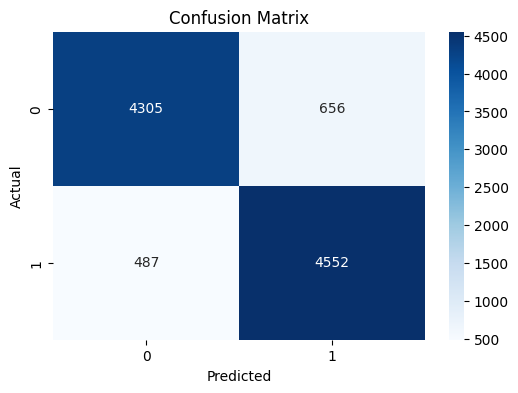

In [ ]:

cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# CONCLUSION

In conclusion, the sentiment analysis project successfully demonstrated how NLP techniques transform raw text into meaningful data for classification. TF-IDF combined with Logistic Regression achieved strong accuracy. The results show that proper preprocessing significantly improves performance. This project highlights the importance of text representation in machine learning applications.

#AI ASSISTANCE LOG

AI assistance was debug to structure the NLP workflow, debug NLTK errors, and improve code efficiency.